# Index Replication

This notebook explores the replication of trend-following indices by combining several trend-following strategies documented in the academic literature with commonly employed industry techniques. The goal is to develop a transparent, rules-based replication that approximates the return characteristics of established trend-following benchmarks.

# Package, Path Management, and Data Load

In [152]:
import os
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from   matplotlib.ticker import FuncFormatter

In [2]:
epost_path = os.getcwd()
root_path  = os.path.abspath(os.path.join(epost_path, ".."))
data_path  = os.path.join(root_path, "data")
trend_path = os.path.join(data_path, "TrendIndices")
tick_path  = os.path.join(data_path, "TickerGuide.xlsx")
fut_path   = os.path.join(data_path, "FuturesData", "PrepFuturesPX.parquet")
idx_path   = os.path.join(epost_path, "IndexReplication.xlsx")

Prep Trend Indices Data

In [36]:
throw_tickers = ["NEIXCTA Index", "DBVTILUU Index", "DBTIDEUU Index", "MLSRUIT5 Index"]

df_idx_ticker = (pd.read_excel(
    io         = idx_path, 
    sheet_name = "TrendIndices").
    query("Currency == 'USD'").
    query("Ticker != @throw_tickers").
    drop(columns = ["Currency"]))

idx_tickers = df_idx_ticker.Ticker.drop_duplicates().sort_values().to_list()
idx_namer   = df_idx_ticker.set_index("Ticker").Name.to_dict()

In [4]:
df_ticker_replication_guide = (pd.read_excel(
    io = idx_path, sheet_name = "IndexReplication"))

Prep Futures Data

In [5]:
def _fix_fx(df: pd.DataFrame) -> pd.DataFrame: 

    df_out = (df.sort_index().assign(
        fx_val  = lambda x: x.fx_val.ffill(),
        adj_val = lambda x: x.fx_val * x.CLEAN_PX))

    return df_out

df_fut_prep = (pd.read_parquet(
    path = fut_path, engine = "pyarrow").
    set_index("date").
    groupby("ticker").
    apply(_fix_fx).
    reset_index())

# Analzying Trend Indices

In [6]:
trend_idx_path     = os.path.join(trend_path, "TrendIndices.parquet")
df_raw_trend_idx   = (pd.read_parquet(
    path = trend_idx_path, engine = "pyarrow").
    query("security == @idx_tickers"))

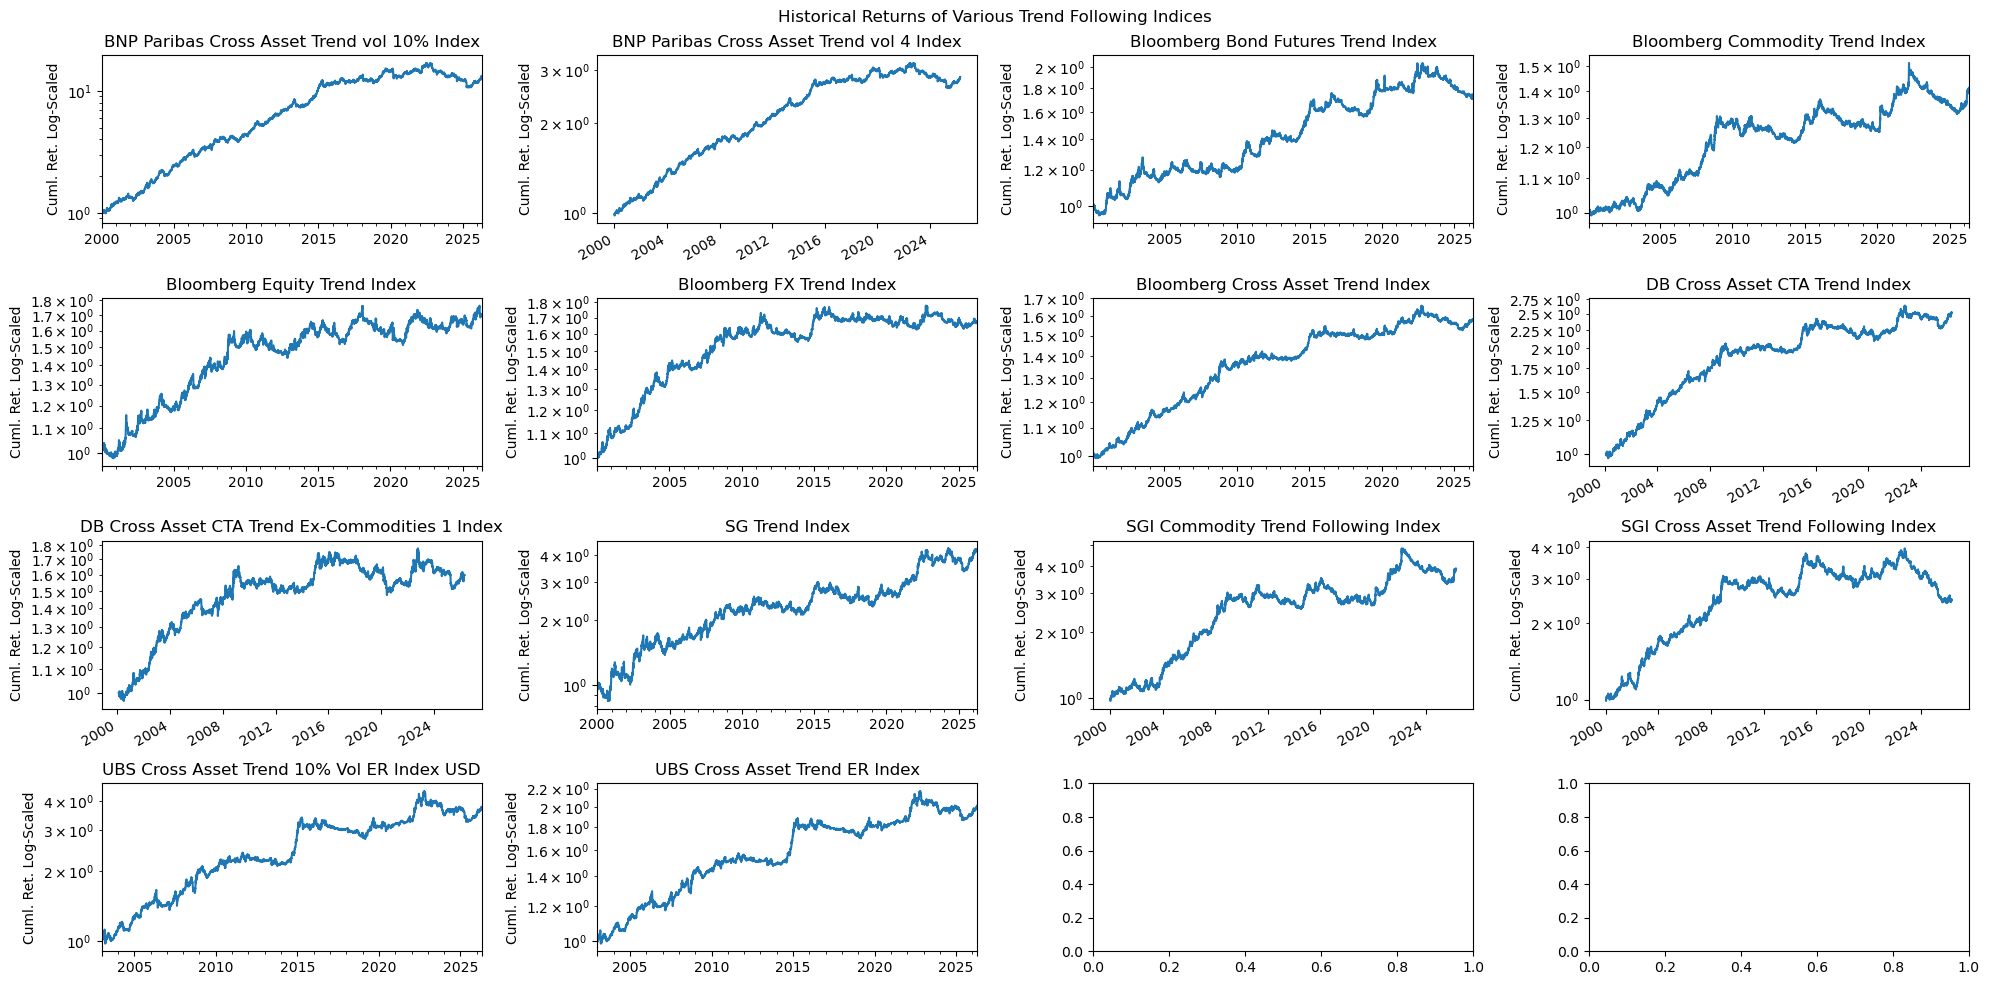

In [7]:
trend_tickers = df_raw_trend_idx.security.drop_duplicates().sort_values().to_list()
fig, axes     = plt.subplots(ncols = 4, nrows = 4, figsize = (20,10))

for ticker, ax in zip(trend_tickers, axes.flatten()): 

    (df_raw_trend_idx.query(
        "security == @ticker").
        set_index("date")
        [["PX_LAST"]].
        sort_index().
        pct_change().
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            ax     = ax,
            logy   = True,
            legend = False,
            ylabel = "Cuml. Ret. Log-Scaled",
            xlabel = "",
            title  = idx_namer[ticker]))

fig.suptitle("Historical Returns of Various Trend Following Indices")
plt.tight_layout()

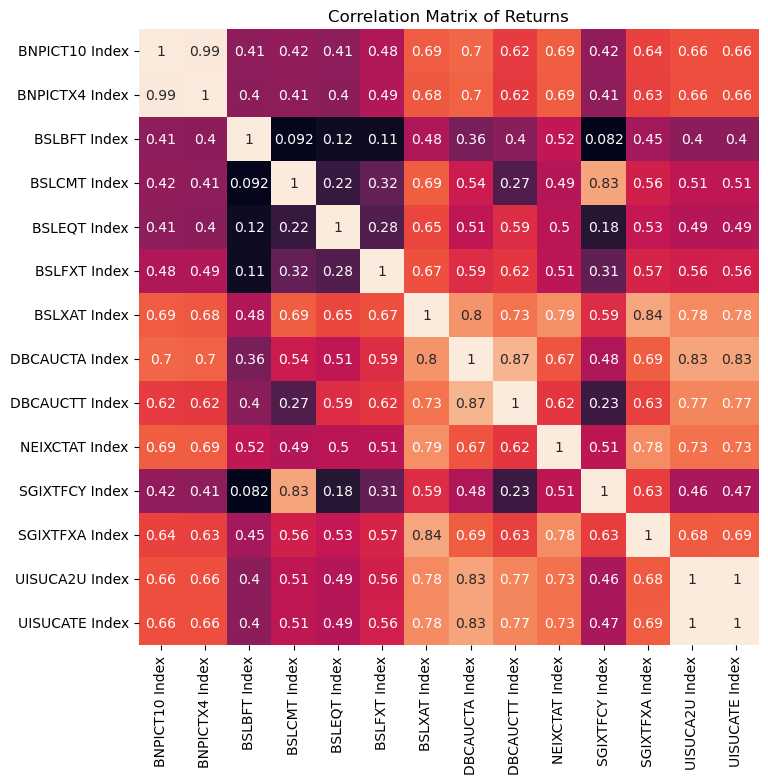

In [8]:
df_corr = (df_raw_trend_idx.pivot(
    index = "date", columns = "security", values = "PX_LAST").
    pct_change().
    corr())

fig, axes = plt.subplots(figsize = (8,8))

sns.heatmap(
    cbar  = False,
    ax    = axes,
    data  = df_corr,
    annot = True)

axes.set_xlabel("")
axes.set_ylabel("")
axes.set_title("Correlation Matrix of Returns")
plt.show()

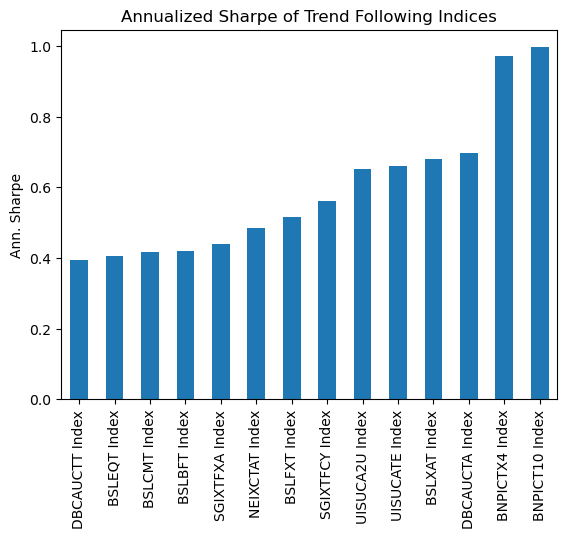

In [9]:
(df_raw_trend_idx.set_index("date").groupby(
    "security").
    apply(lambda x: x.sort_index().pct_change()).
    reset_index().
    drop(columns = ["date"]).
    groupby("security").
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    sort_values("PX_LAST").
    plot(
        kind   = "bar", 
        legend = False, 
        ylabel = "Ann. Sharpe",
        title  = "Annualized Sharpe of Trend Following Indices",
        xlabel = ""))

plt.show()

# Ticker Selection and Signal Generation

The available options for futures trading is a large expensive list

In [10]:
def _get_trend_rtn(
    df           : pd.DataFrame,
    trend_window : int   = 100,
    hetero_window: int   = 10,
    vol_target   : float = 0.1,
    vol_window   : int   = 100) -> pd.DataFrame: 

    df_out = (df.sort_index().assign(
        px_diff    = lambda x: x.px.diff(),
        px_dt      = lambda x: x.px_diff / x.px_diff.ewm(span = hetero_window, adjust = False).std(),
        signal     = lambda x: x.px_dt.ewm(span = trend_window, adjust = False).mean().shift(),
        px_rtn     = lambda x: x.px.pct_change(),
        signal_rtn = lambda x: np.sign(x.signal) * x.px_rtn,
        weight     = lambda x: vol_target / (x.signal_rtn.ewm(span = vol_window, adjust = False).std() * np.sqrt(252)),
        weight_rtn = lambda x: x.weight * x.signal_rtn))

    return df_out

In [11]:
def get_trend_signal(
    df_px       : pd.DataFrame,
    ticker_dict : dict,
    trend_signal: int = 100,
    vol_window  : int = 10) -> pd.DataFrame: 

    df_lists = []
    
    for key in ticker_dict.keys():
    
        raw_tickers = ticker_dict[key]
        tmp_tickers = [ticker.lower().replace(" 1", "1").replace(" ", "_") for ticker in raw_tickers]
    
        df_add = (df_px.query(
            "ticker == @tmp_tickers")
            [["date", "adj_val", "ticker"]].
            assign(asset_class = key).
            rename(columns = {"adj_val": "px"}))
    
        df_lists.append(df_add)
    
    df_px         = pd.concat(df_lists)
    df_signal_rtn = (df_px.set_index(
        "date").
        groupby("ticker").
        apply(_get_trend_rtn, trend_signal, vol_window).
        reset_index())

    return df_signal_rtn

In [12]:
groups   = df_ticker_replication_guide.group.drop_duplicates().sort_values().to_list()
df_lists = []

for group in groups: 

    ticker_dict = (df_ticker_replication_guide.query(
        "group == @group")
        [["asset_class", "ticker"]].
        dropna().
        groupby("asset_class").
        agg(list).
        ticker.
        to_dict())

    df_tmp = get_trend_signal(df_fut_prep, ticker_dict).assign(group = group)
    df_lists.append(df_tmp)

df_signal_rtn = pd.concat(df_lists)

# Comparing Returns

In [22]:
df_idx_rtn = (df_raw_trend_idx.set_index(
    "date").
    groupby("security").
    apply(lambda x: x.sort_index().pct_change()).
    rename(columns = {"PX_LAST": "idx_rtn"}).
    reset_index().
    assign(date = lambda x: pd.to_datetime(x.date).dt.date))

In [92]:
tickers  = df_idx_ticker.Ticker.drop_duplicates().sort_values()
df_lists = []

for ticker in tickers: 

    ticker_info = (df_idx_ticker.query(
        "Ticker == @ticker").
        reset_index(drop = True).
        to_dict(orient = "index")
        [0])

    tmp_idx_ticker       = ticker_info["Ticker"]
    raw_idx_asset_class  = ticker_info["selector"]
    tmp_idx_asset_class  = raw_idx_asset_class.replace("'", "").replace("[", "").replace("]","").split(",")
    prep_idx_asset_class = [ticker.lstrip().strip() for ticker in tmp_idx_asset_class]
    
    df_idx_tmp  = df_idx_rtn.query("security == @tmp_idx_ticker")
    df_tmp_repl = (df_signal_rtn.query(
        "asset_class == @prep_idx_asset_class")
        [["date", "group", "weight_rtn"]].
        dropna().
        groupby(["date", "group"]).
        agg("sum").
        reset_index().
        assign(weight_rtn = lambda x: np.where(np.abs(x.weight_rtn) > 0.1, np.nan, x.weight_rtn)).
        dropna())

    df_tmp_repl_wider = (df_tmp_repl.pivot(
        index = "date", columns = "group", values = "weight_rtn"))

    df_repl_vol = (df_tmp_repl.pivot(
        index = "date", columns = "group", values = "weight_rtn").
        apply(lambda x: x.ewm(span = 100, adjust = False).std()))

    df_idx_vol = (df_idx_tmp.set_index(
        "date")
        [["idx_rtn"]].
        apply(lambda x: x.ewm(span = 100, adjust = False).std()))

    df_rescaled = ((1 / df_repl_vol.div(df_idx_vol["idx_rtn"], axis = 0).ffill().bfill()) * df_tmp_repl_wider).dropna()
    df_add      = (df_rescaled.merge(
        right = df_idx_tmp, how = "inner", on = ["date"]).
        drop(columns = ["security"]).
        set_index("date").
        assign(name = ticker_info["PlotName"]))

    df_lists.append(df_add)

df_benchmark_compare = pd.concat(df_lists)

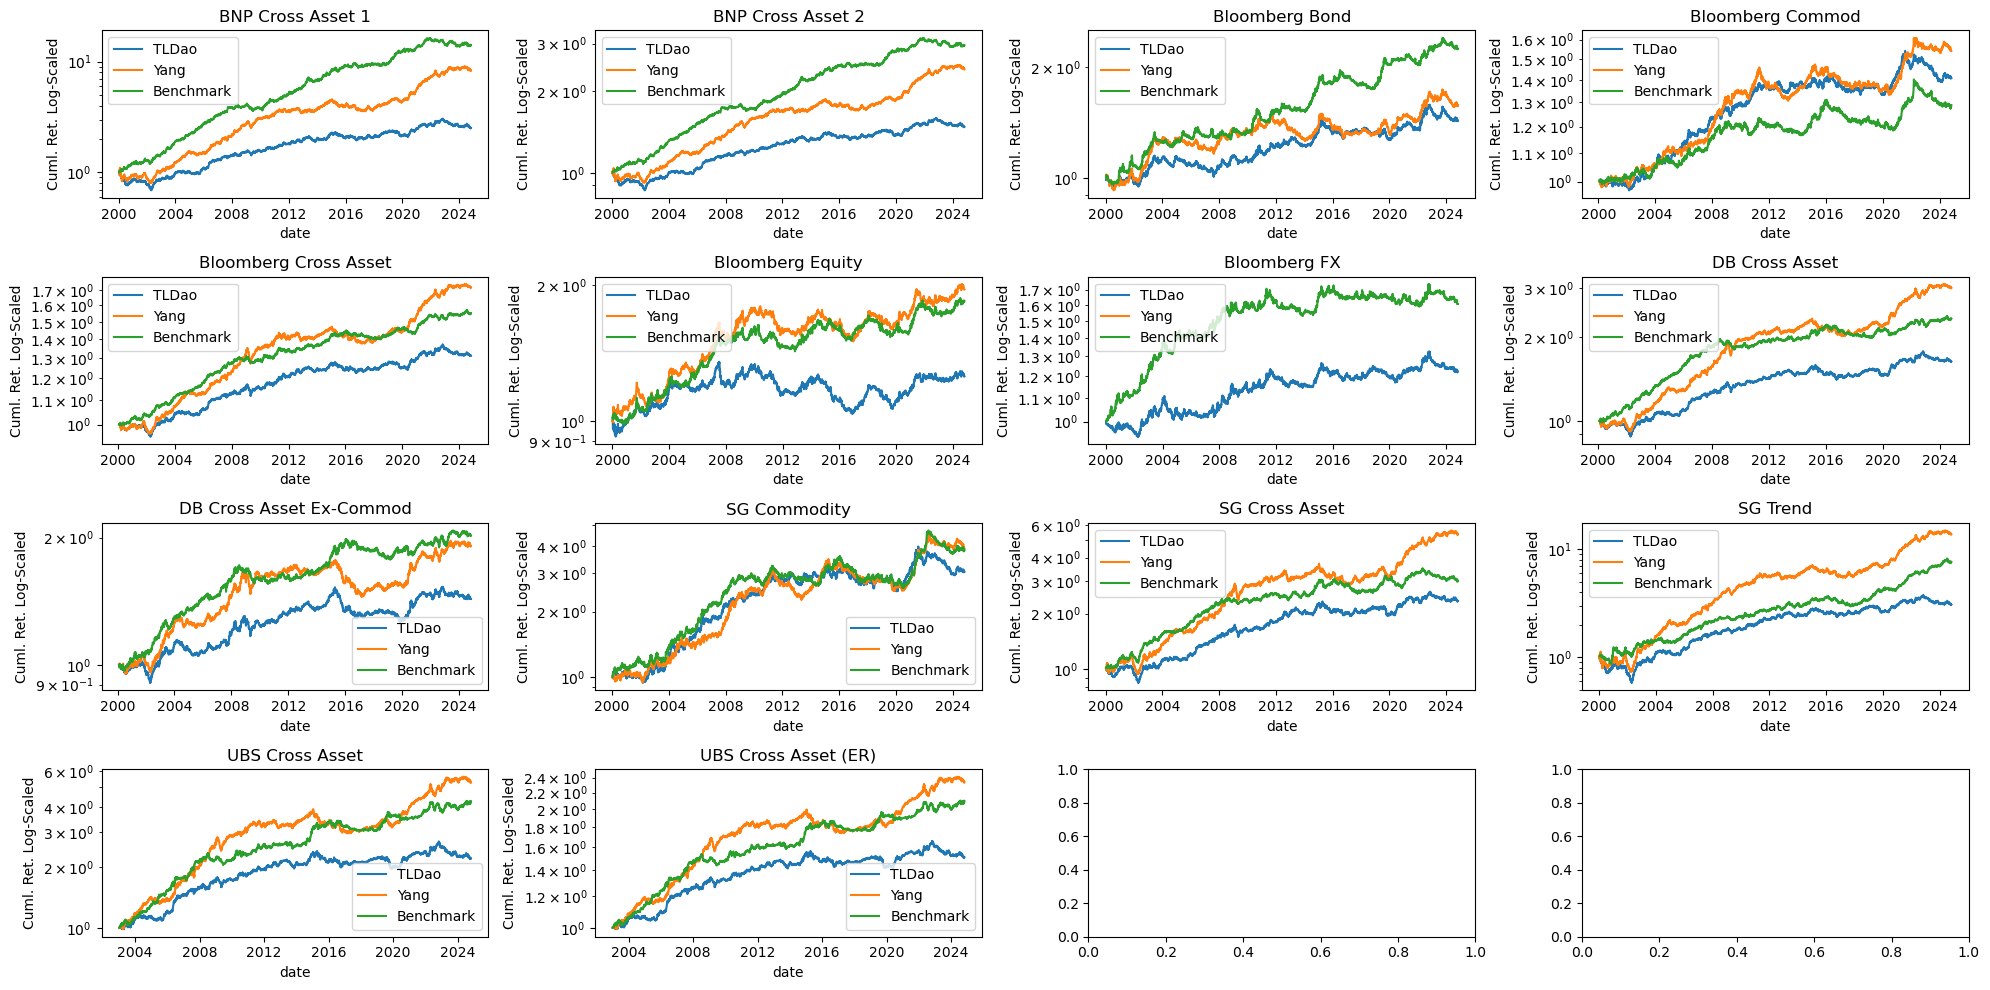

In [106]:
names     = df_benchmark_compare.name.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = 4, nrows = 4, figsize = (20,10))

for name, ax in zip(names, axes.flatten()):

    (df_benchmark_compare.query(
        "name == @name").
        drop(columns = ["name"]).
        rename(columns = {"idx_rtn": "Benchmark"}).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            ax     = ax,
            logy   = True,
            title  = name,
            ylabel = "Cuml. Ret. Log-Scaled"))

fig.suptitle("Comparing Benchmark Returns vs. eq")
plt.tight_layout()

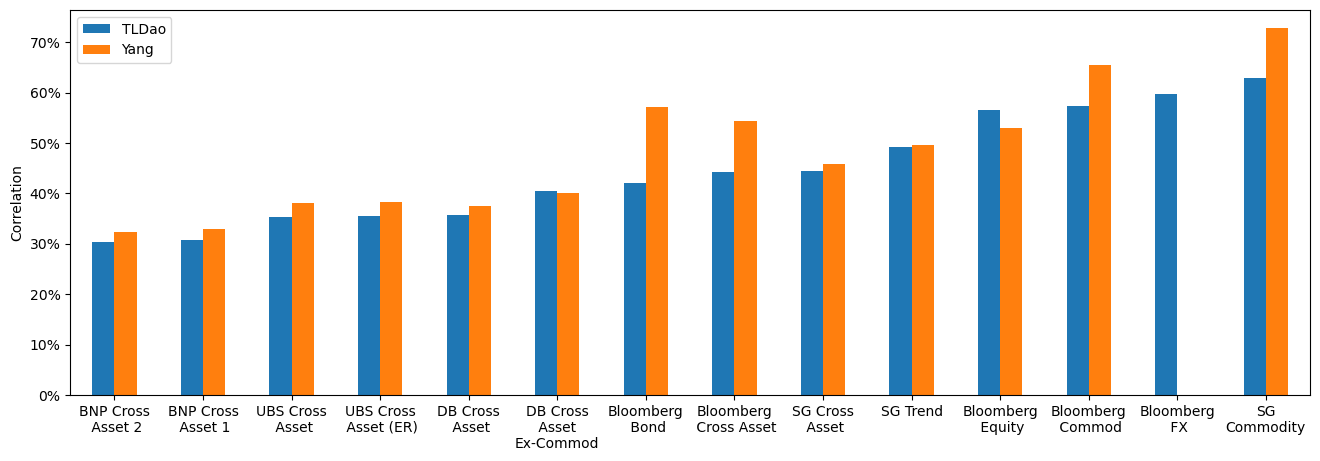

In [159]:
_, axes = plt.subplots(figsize = (16,5))

(df_benchmark_compare.reset_index().melt(
    id_vars = ["name", "idx_rtn", "date"]).
    drop(columns = ["date"]).
    groupby(["variable", "name"]).
    agg("corr").
    dropna().
    query("value != 1").
    reset_index().
    assign(name = lambda x: (
        x.name
            .str.replace("Bloomberg", "Bloomberg\n", regex = False)
            .str.replace("BNP Cross", "BNP Cross\n", regex = False)
            .str.replace("UBS Cross", "UBS Cross\n", regex = False)
            .str.replace("SG Cross", "SG Cross\n"  , regex = False)
            .str.replace("DB Cross", "DB Cross\n"  , regex = False)
            .str.replace("Ex-Commod", "\nEx-Commod", regex = False)
            .str.replace("SG Commodity","SG\nCommodity", regex = False))).
    rename(columns = {"variable": ""}).
    pivot(index = "name", columns = "", values = "value").
    sort_values(["TLDao", "Yang"]).
    plot(
        kind    = "bar", 
        rot     = 0, 
        ax      = axes,
        xlabel  = "",
        ylabel  = "Correlation",
        title   = ""))

axes.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f"{y:.0%}"))

In [ ]:
df_replicated = (df_signal_rtn[
    ["date", "group", "weight_rtn"]].
    dropna().
    groupby(["date", "group"]).
    agg("sum").
    reset_index().
    rename(columns = {"group": ""}).
    pivot(index = "date", columns = "", values = "weight_rtn").
    apply(lambda x: np.where(np.abs(x) > 0.1, np.nan, x)).
    dropna())

In [ ]:
multi_tickers = (df_idx_ticker.rename(columns = {
    "Asset Class": "asset_class"}).
    query("asset_class == 'Multi Asset'").
    Ticker.
    drop_duplicates().
    sort_values().
    to_list())

In [ ]:
df_combined = (df_idx_rtn.query(
    "security == @multi_tickers").
    merge(right = df_replicated, how = "inner", on = ["date"]))

In [ ]:
df_corr = (df_combined.melt(
    id_vars = ["date", "security", "idx_rtn"]).
    drop(columns = ["date"]).
    groupby(["security", "variable"]).
    agg("corr").
    query("value != 1").
    drop(columns = ["idx_rtn"]).
    reset_index().
    rename(columns = {"variable": ""}).
    assign(security = lambda x: x.security.str.split(" ").str[0]).
    pivot(index = "security", columns = "", values = "value").
    sort_values(["TLDao", "Yang"]))

In [ ]:
start_date = df_combined[["security", "date"]].groupby("security").agg("min").date.max()

In [ ]:
df_plot = (df_combined.assign(
    security = lambda x: x.security.str.split(" ").str[0]).
    query("date >= @start_date").
    rename(columns = {"security": ""}).
    pivot(index = ["date", "TLDao", "Yang"], columns = "", values = "idx_rtn").
    reset_index().
    set_index("date").
    assign(
        TLDao = lambda x: x.TLDao * (0.4 / (x.TLDao.ewm(span = 100, adjust = False).std() * np.sqrt(252))),
        Yang  = lambda x: x.Yang * (0.15 / (x.Yang.ewm(span = 100, adjust = False).std() * np.sqrt(252)))))

In [ ]:
fig, axes = plt.subplots(ncols = 2, figsize = (20,6))

(df_corr.plot(
    ax     = axes[0],
    kind   = "bar", 
    xlabel = "", 
    rot    = 0,
    ylabel = "Correlation",
    title  = "Correlation of Replicated Returns to Benchmarks"))

(df_plot.drop(
    columns = ["TLDao", "Yang"]).
    dropna().
    apply(lambda x: x * (0.2 / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.cumprod(1 + x)).
    plot(
        ax     = axes[1],
        logy   = True, 
        legend = False,
        color  = "skyblue",
        alpha  = 0.6))

(df_plot[
    ["TLDao", "Yang"]].
    apply(lambda x: np.cumprod(1 + x)).
    plot(
        logy   = True,
        ax     = axes[1],
        color  = ["red", "green"],
        ylabel = "Cuml. Ret. Log-Scaled",
        title  = "Cumulative Returns of Trend Following Returns"))

fig.suptitle("Comparing Replicated Returns to Benchmark")
plt.tight_layout()

# Breaking out By asset class

In [ ]:
asset_mapper = {
    "Commodity"   : "commod",
    "Equity"      : "equity",
    "FX"          : "fx",
    "Fixed Income": ["govt", "stir"]}

df_asset_ticker = (df_idx_ticker.rename(
    columns = {"Asset Class": "asset_class"}).
    query("asset_class == ['Commodity', 'FX', 'Fixed Income', 'Equity']").
    assign(new_asset = lambda x: x.asset_class.map(asset_mapper)))

In [ ]:
asset_classes = df_asset_ticker.new_asset.drop_duplicates().to_list()
df_lists      = []

for asset_class in asset_classes:

    df_tmp_signal_rtn = (df_signal_rtn.query(
        "asset_class == @asset_class")
        [["date", "group", "weight_rtn"]].
        groupby(["date", "group"]).
        agg("mean").
        reset_index().
        dropna())

    tmp_tickers = (df_asset_ticker.query(
        "new_asset == @asset_class").
        Ticker.
        drop_duplicates().
        sort_values().
        to_list())
    
    df_tmp_idx = (df_idx_rtn.query(
        "security == @tmp_tickers").
        assign(
            security = lambda x: x.security.str.split(" ").str[0]))

    df_add = (df_tmp_signal_rtn.merge(
        right = df_tmp_idx, how = "inner", on = ["date"]).
        assign(asset_class = asset_class))

    df_lists.append(df_add)

df_compare = pd.concat(df_lists)

In [ ]:
(df_compare.drop(
    columns = ["date"]).
    groupby(["group", "asset_class", "security"]).
    agg("corr").
    reset_index().
    query("idx_rtn != 1").
    rename(columns = {"group": ""}).
    pivot(index = "security", columns = "", values = "idx_rtn").
    plot(
        kind    = "bar", 
        rot     = 0,
        ylabel  = "Correlation",
        xlabel  = "",
        title   = "Correlation of Each Individual Asset to its respective Benchmark",
        figsize = (8,5)))

In [ ]:
asset_classes = df_compare.query("asset_class != 'stir'").asset_class.drop_duplicates().sort_values().to_list()
for asset_class in asset_classes: 

    df_tmp = (df_compare.query(
        "asset_class == @asset_class"))

    df_repl_tmp = (df_tmp[
        ["date", "group", "weight_rtn"]].
        drop_duplicates().
        pivot(index = "date", columns = "group", values = "weight_rtn"))

    df_idx_tmp = (df_tmp[
        ["date", "security", "idx_rtn"]].
        drop_duplicates().
        pivot(index = "date", columns = "security", values = "idx_rtn"))

    display(df_repl_tmp.merge(
        right = df_idx_tmp, how = "inner", on = ["date"]).
        dropna().
        apply(lambda x: np.cumprod(1 + x)).
        plot(logy = True, title = asset_class))

    plt.show()

# References

@article{dao2017tail,
  title   = {Tail Protection for Long Investors: Trend Convexity at Work},
  author  = {Dao, Tung-Lam and Nguyen, Trung-Tu and Deremble, Cyril and Lemp{\'e}ri{\`e}re, Yves and Bouchaud, Jean-Philippe and Potters, Marc},
  journal = {Journal of Investment Strategies},
  volume  = {7},
  number  = {1},
  pages   = {61--84},
  year    = {2017},
  doi     = {10.21314/JOIS.2017.093}
}